# Chapter 2 — The singular value decomposition

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 2](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02) of the notes. Every
experiment checks a statement of the chapter numerically, and every
verification uses a tolerance derived from an error bound.

**Learning objectives.** After working through this lab you should be able to

1. compute full, thin and compact SVDs with NumPy and verify them;
2. read off rank, bases of the four fundamental subspaces, norms and the
   condition number from an SVD;
3. check the relation between singular values and the eigenvalues of
   $A^TA$ and of the augmented matrix, and demonstrate why singular values
   must not be computed from $A^TA$;
4. verify the Eckart--Young--Mirsky theorem and Weyl's perturbation bound
   from *computed* errors rather than assuming them;
5. choose a tolerance for the numerical rank and for the pseudoinverse, and
   compute minimum-norm least-squares solutions.

Run the cells in order from a fresh kernel.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla

rng = np.random.default_rng(20260202)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}, SciPy {scipy.__version__}; unit roundoff u = {u:.3e}")


def random_orthonormal(m, n):
    """An m x n matrix with orthonormal columns (Q factor of a Gaussian matrix)."""
    Q, _ = np.linalg.qr(rng.standard_normal((m, n)))
    return Q

NumPy 2.5.3, SciPy 1.18.1; unit roundoff u = 1.110e-16


## 1. Full, thin and compact SVD

`numpy.linalg.svd(A)` returns `U`, the singular values `s` as a
one-dimensional array in decreasing order, and `Vh` $= V^T$ (not $V$). By
default it computes the *full* SVD; `full_matrices=False` gives the *thin*
SVD.

**Tolerances.** The SVD computed by LAPACK is backward stable: the computed
factors are orthogonal to within a small multiple of $u$ and reproduce $A$
with a relative error that is a modest multiple of $u$, growing at most
mildly with the dimension. We test against $10\max(m,n)\,u$, which leaves a
wide margin while still detecting any real error (a wrong sign or a
transposed factor gives errors of order one).

In [2]:
m, n = 8, 5
A = rng.standard_normal((m, n))

U, s, Vh = np.linalg.svd(A)                              # full SVD
Ut, st, Vht = np.linalg.svd(A, full_matrices=False)      # thin SVD
print("full :", U.shape, s.shape, Vh.shape)
print("thin :", Ut.shape, st.shape, Vht.shape)

Sigma = np.zeros((m, n))
np.fill_diagonal(Sigma, s)
tol = 10 * max(m, n) * u
checks = {
    "||U^T U - I||_2": np.linalg.norm(U.T @ U - np.eye(m), 2),
    "||V^T V - I||_2": np.linalg.norm(Vh @ Vh.T - np.eye(n), 2),
    "||A - U Sigma V^T||_2 / ||A||_2 (full)": np.linalg.norm(A - U @ Sigma @ Vh, 2) / s[0],
    "||A - U_n Sigma_n V^T||_2 / ||A||_2 (thin)": np.linalg.norm(A - (Ut * st) @ Vht, 2) / s[0],
}
for name, val in checks.items():
    print(f"{name:45s} {val:.2e}")
    assert val < tol
assert np.all(np.diff(s) <= 0) and np.all(s >= 0)       # sorted, nonnegative
print(f"tolerance 10 max(m,n) u = {tol:.1e}")

full : (8, 8) (5,) (5, 5)
thin : (8, 5) (5,) (5, 5)
||U^T U - I||_2                               1.98e-15
||V^T V - I||_2                               1.44e-15
||A - U Sigma V^T||_2 / ||A||_2 (full)        1.42e-15
||A - U_n Sigma_n V^T||_2 / ||A||_2 (thin)    1.42e-15
tolerance 10 max(m,n) u = 8.9e-15


Note the idiom `(Ut * st) @ Vht`: multiplying the columns of $U$ by the
singular values with broadcasting costs $mn$ flops, whereas forming
`np.diag(st)` and multiplying costs $2mn^2$.

The *compact* SVD keeps only the $r$ columns belonging to nonzero singular
values. For a matrix of exact rank 3 the computed singular values
$\sigma_4,\sigma_5$ are not zero but of order $u\sigma_1$, so "nonzero" needs
a tolerance (Section 4).

In [3]:
X = rng.standard_normal((m, 3))
Y = rng.standard_normal((3, n))
A3 = X @ Y                                               # rank 3 in exact arithmetic
U3, s3, Vh3 = np.linalg.svd(A3, full_matrices=False)
print("singular values:", np.array2string(s3, precision=3))
print("sigma_4 / (u sigma_1) =", s3[3] / (u * s3[0]))
r = int(np.sum(s3 > max(m, n) * np.finfo(float).eps * s3[0]))
Ur, sr, Vhr = U3[:, :r], s3[:r], Vh3[:r]
print(f"compact SVD: r = {r}, shapes {Ur.shape}, {sr.shape}, {Vhr.shape}")
assert r == 3
assert np.linalg.norm(A3 - (Ur * sr) @ Vhr, 2) < tol * s3[0]

singular values: [8.707e+00 5.887e+00 3.777e+00 1.189e-15 3.932e-16]
sigma_4 / (u sigma_1) = 1.229819893738462
compact SVD: r = 3, shapes (8, 3), (3,), (3, 5)


The trailing singular values are of the order of $u\sigma_1$, exactly the
size predicted by the perturbation bound
$|\sigma_i(A+E)-\sigma_i(A)|\le\|E\|_2$ with $\|E\|_2$ of the order of the
rounding errors made in forming `X @ Y`.

## 2. The worked example

[Example 2.1](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-exa-svd-by-hand) found, for $B = \begin{bmatrix}3&0\\4&5\end{bmatrix}$,
$\sigma_1 = 3\sqrt5$, $\sigma_2 = \sqrt5$,
$U = \tfrac1{\sqrt{10}}\begin{bmatrix}1&3\\3&-1\end{bmatrix}$ and
$V = \tfrac1{\sqrt2}\begin{bmatrix}1&1\\1&-1\end{bmatrix}$. Singular vectors
are unique only up to simultaneous sign changes of $(u_i, v_i)$, so we compare
after normalizing signs.

In [4]:
B = np.array([[3.0, 0.0], [4.0, 5.0]])
U_hand = np.array([[1.0, 3.0], [3.0, -1.0]]) / np.sqrt(10)
V_hand = np.array([[1.0, 1.0], [1.0, -1.0]]) / np.sqrt(2)
s_hand = np.array([3 * np.sqrt(5), np.sqrt(5)])

UB, sB, VhB = np.linalg.svd(B)
signs = np.sign(np.sum(VhB.T * V_hand, axis=0))          # +1 or -1 for each pair
print("NumPy U:\n", UB, "\nNumPy V:\n", VhB.T, "\nsingular values:", sB)
assert np.allclose(sB, s_hand, rtol=10 * u, atol=0)
assert np.allclose(UB * signs, U_hand, rtol=0, atol=10 * u) and np.allclose(VhB.T * signs, V_hand, rtol=0, atol=10 * u)
print("agrees with the hand computation up to the signs", signs)

NumPy U:
 [[-0.31622777 -0.9486833 ]
 [-0.9486833   0.31622777]] 
NumPy V:
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]] 
singular values: [6.70820393 2.23606798]
agrees with the hand computation up to the signs [-1. -1.]


## 3. Geometry: the image of the unit circle

For a $2\times2$ matrix the image of the unit circle is an ellipse with
semi-axes $\sigma_1u_1$ and $\sigma_2u_2$ ([Theorem 2.2](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-thm-ellipsoid)).
We check numerically that the largest and smallest values of $\|Ax\|_2$ on
the circle are $\sigma_1$ and $\sigma_2$.

max ||Ax|| on the grid = 0.994536, sigma_1 = 0.994536
min ||Ax|| on the grid = 0.258760, sigma_2 = 0.258760


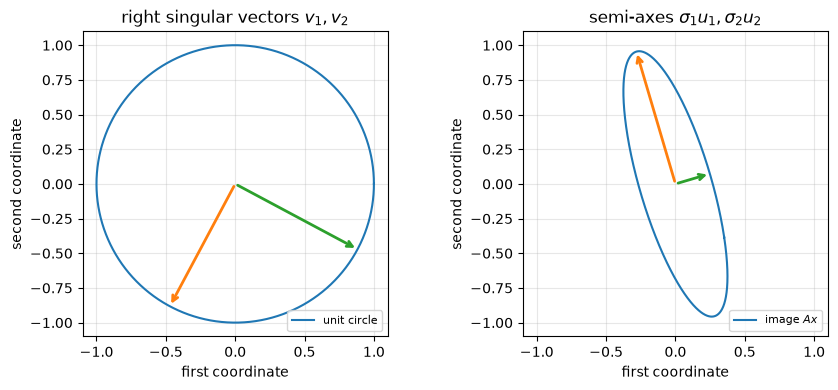

In [5]:
A2 = rng.standard_normal((2, 2))
U2, s2, Vh2 = np.linalg.svd(A2)
t = np.linspace(0, 2 * np.pi, 2001)
circle = np.vstack([np.cos(t), np.sin(t)])
image = A2 @ circle
lengths = np.linalg.norm(image, axis=0)
print(f"max ||Ax|| on the grid = {lengths.max():.6f}, sigma_1 = {s2[0]:.6f}")
print(f"min ||Ax|| on the grid = {lengths.min():.6f}, sigma_2 = {s2[1]:.6f}")
# The grid point nearest to v_1 (or v_2) is at most dtheta = pi/2000 away from it. At angle
# dtheta from v_1, ||Ax||_2 >= sigma_1 cos(dtheta); at angle dtheta from v_2,
# ||Ax||_2 <= (sigma_2^2 + sigma_1^2 sin^2(dtheta))^(1/2). 10u covers rounding in ||Ax||_2.
dtheta = np.pi / 2000
assert s2[0] * np.cos(dtheta) * (1 - 10 * u) <= lengths.max() <= s2[0] * (1 + 10 * u)
assert s2[1] * (1 - 10 * u) <= lengths.min() <= np.hypot(s2[1], s2[0] * np.sin(dtheta)) * (1 + 10 * u)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(*circle, label="unit circle")
for i, c in enumerate(("C1", "C2")):
    axes[0].annotate("", xy=Vh2[i], xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    axes[1].annotate("", xy=s2[i] * U2[:, i], xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
axes[1].plot(*image, label="image $Ax$")
axes[0].set_title(r"right singular vectors $v_1, v_2$")
axes[1].set_title(r"semi-axes $\sigma_1 u_1, \sigma_2 u_2$")
lim = 1.1 * max(1.0, s2[0])
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("first coordinate")
    ax.set_ylabel("second coordinate")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

The arrows on the right lie exactly on the semi-axes of the ellipse. This is
[Figure 2.1](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-fig-svd-geometry) for a random matrix.

## 4. Rank, fundamental subspaces, and numerical rank

We return to the matrix `A3` of exact rank 3 and extract orthonormal bases of
its four fundamental subspaces from the SVD ([Theorem 2.3](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-thm-subspaces)).
Because of rounding, $A v_i$ for $i>3$ is not exactly zero but of size
$\sigma_i\approx u\sigma_1$; we test against $10\max(m,n)u\,\sigma_1$.

In [6]:
U3f, s3f, Vh3f = np.linalg.svd(A3)                       # full SVD: bases of all of R^m and R^n
r = 3
range_A, null_At = U3f[:, :r], U3f[:, r:]
range_At, null_A = Vh3f[:r].T, Vh3f[r:].T
print("dimensions:", range_A.shape[1], null_At.shape[1], range_At.shape[1], null_A.shape[1])
small = 10 * max(m, n) * u * s3f[0]
print(f"||A  N(A)||_2   = {np.linalg.norm(A3 @ null_A, 2):.1e}")
print(f"||A^T N(A^T)||_2 = {np.linalg.norm(A3.T @ null_At, 2):.1e}")
assert np.linalg.norm(A3 @ null_A, 2) < small and np.linalg.norm(A3.T @ null_At, 2) < small
# range(A) is spanned by the columns of X; the projector onto it must fix X.
P = range_A @ range_A.T
print(f"||(I - P) X||_2 / ||X||_2 = {np.linalg.norm(X - P @ X, 2) / np.linalg.norm(X, 2):.1e}")
assert np.linalg.norm(X - P @ X, 2) < 100 * max(m, n) * u * np.linalg.norm(X, 2) * s3f[0] / s3f[r - 1]

dimensions: 3 5 3 2
||A  N(A)||_2   = 3.4e-15
||A^T N(A^T)||_2 = 8.1e-16
||(I - P) X||_2 / ||X||_2 = 2.2e-16


The last tolerance contains the factor $\sigma_1/\sigma_r$: the computed
singular subspace for $\sigma_1,\dots,\sigma_r$ is accurate to about
$u\sigma_1/(\sigma_r-\sigma_{r+1})$, a gap-dependent bound that we will meet
again for eigenvectors in [Chapter 9](https://aalsammani.github.io/numerical-linear-algebra/ch09-eigenvalues/notes.html#ch09).

**Numerical rank.** `numpy.linalg.matrix_rank` counts singular values larger
than $\tau = \max(m,n)\,\epsilon_{\text{mach}}\,\sigma_1$. That default is
right for rounding errors. For data with noise it is wrong, as the next cell
shows for the matrix of [Example 2.5](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-exa-noisy-low-rank).

In [7]:
rng11 = np.random.default_rng(11)                        # same matrix as the notes and the figure
L = rng11.standard_normal((60, 8))
R = rng11.standard_normal((8, 60))
E = rng11.standard_normal((60, 60))
A_hat = L @ R                                            # rank 8
N = 0.05 * E                                             # noise
A_noisy = A_hat + N
s_noisy = np.linalg.svd(A_noisy, compute_uv=False)
eta = np.linalg.norm(N, 2)
print(f"sigma_8 = {s_noisy[7]:.4g}, sigma_9 = {s_noisy[8]:.4g}, ||noise||_2 = {eta:.4g}")
print("default matrix_rank:", np.linalg.matrix_rank(A_noisy))
for tau in (1e-10, 1e-2, eta, 1.0, 10.0, 40.0):
    print(f"tau = {tau:8.3g}:  rank_tau = {int(np.sum(s_noisy > tau))}")
# Proposition ch02-prop-numerical-rank (2): tau >= eta and sigma_8(A_hat) > tau + eta give rank 8.
s_hat8 = np.linalg.svd(A_hat, compute_uv=False)[7]
assert s_hat8 > 2 * eta and int(np.sum(s_noisy > eta)) == 8
# Weyl: sigma_9(A) <= sigma_9(A_hat) + eta = eta, up to rounding of order n u sigma_1 in
# forming A_hat = L R and in the SVD.
assert s_noisy[8] <= eta + 10 * 60 * u * s_noisy[0]

sigma_8 = 36.33, sigma_9 = 0.6503, ||noise||_2 = 0.7195
default matrix_rank: 60
tau =    1e-10:  rank_tau = 60
tau =     0.01:  rank_tau = 60
tau =    0.719:  rank_tau = 8
tau =        1:  rank_tau = 8
tau =       10:  rank_tau = 8
tau =       40:  rank_tau = 7


The default tolerance reports full rank 60, because the noise singular values
(about $0.01$ to $0.65$) are far above rounding level. Any tolerance between
the noise level $\|N\|_2\approx0.72$ and $\sigma_8\approx36$ gives rank 8.
[Proposition 2.2](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-prop-numerical-rank) guarantees this in advance, without
looking at the computed singular values of $A$, for every $\tau$ with
$\|N\|_2\le\tau<\sigma_8(\hat A)-\|N\|_2\approx35.6$.

## 5. Norms and the condition number

In [8]:
n = 50
A = rng.standard_normal((n, n))
s = np.linalg.svd(A, compute_uv=False)
Ainv = np.linalg.inv(A)
rows = [
    ("||A||_2 vs sigma_1", np.linalg.norm(A, 2), s[0]),
    ("||A||_F vs sqrt(sum sigma_i^2)", np.linalg.norm(A, "fro"), np.sqrt(np.sum(s**2))),
    ("||A^-1||_2 vs 1/sigma_n", np.linalg.norm(Ainv, 2), 1 / s[-1]),
    ("cond(A) vs sigma_1/sigma_n", np.linalg.cond(A), s[0] / s[-1]),
    ("|det A| vs prod sigma_i", abs(np.linalg.det(A)), np.prod(s)),
]
kappa = s[0] / s[-1]
for name, lhs, rhs in rows:
    print(f"{name:32s} {lhs:12.6g} {rhs:12.6g}   rel. diff {abs(lhs - rhs) / abs(rhs):.1e}")
# Norms computed from the same SVD agree to O(n u). The inverse is computed by LU,
# so its 2-norm carries a relative error of order kappa u (Chapter 4).
for name, lhs, rhs in rows[:2]:
    assert abs(lhs - rhs) <= 10 * n * u * rhs
assert abs(rows[2][1] - rows[2][2]) <= 10 * n * kappa * u * rows[2][2]
assert abs(rows[4][1] - rows[4][2]) <= 10 * n * n * u * rows[4][2]  # n^2 u: products of n factors
print(f"kappa_2(A) = {kappa:.3g}")

||A||_2 vs sigma_1                     14.242       14.242   rel. diff 0.0e+00
||A||_F vs sqrt(sum sigma_i^2)        51.1796      51.1796   rel. diff 0.0e+00
||A^-1||_2 vs 1/sigma_n               3.74936      3.74936   rel. diff 2.8e-15
cond(A) vs sigma_1/sigma_n            53.3983      53.3983   rel. diff 0.0e+00
|det A| vs prod sigma_i           3.22058e+32  3.22058e+32   rel. diff 2.2e-16
kappa_2(A) = 53.4


## 6. Singular values and eigenvalues

[Theorem 2.5](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-thm-eigen): the eigenvalues of $A^TA$ are $\sigma_i^2$ (and
$n-p$ zeros), and those of the augmented matrix
$C = \begin{bmatrix}0&A^T\\A&0\end{bmatrix}$ are $\pm\sigma_i$ and $|m-n|$
zeros. We check both for a $7\times4$ matrix, for which $C$ is $11\times11$
and must have $3$ zero eigenvalues although $A$ has full rank.

In [9]:
m, n = 7, 4
A = rng.standard_normal((m, n))
s = np.linalg.svd(A, compute_uv=False)
lam_AtA = np.sort(np.linalg.eigvalsh(A.T @ A))[::-1]
C = np.block([[np.zeros((n, n)), A.T], [A, np.zeros((m, m))]])
lam_C = np.sort(np.linalg.eigvalsh(C))
print("sigma_i^2         :", np.array2string(s**2, precision=6))
print("eig(A^T A)        :", np.array2string(lam_AtA, precision=6))
print("eig(C)            :", np.array2string(lam_C, precision=6))
expected = np.sort(np.concatenate([s, -s, np.zeros(abs(m - n))]))
# A backward stable symmetric eigensolver has absolute eigenvalue errors O((m+n) u ||C||_2), ||C||_2 = sigma_1.
assert np.max(np.abs(lam_C - expected)) < 10 * (m + n) * u * s[0]
assert np.max(np.abs(lam_AtA - s**2)) < 10 * n * u * s[0] ** 2
n_zero = int(np.sum(np.abs(lam_C) < 10 * (m + n) * u * s[0]))
print(f"zero eigenvalues of C: {n_zero} (|m - n| = {abs(m - n)}); C is singular although rank(A) = {n}")
assert n_zero == abs(m - n)

sigma_i^2         : [12.113528  6.572129  5.400481  1.083553]
eig(A^T A)        : [12.113528  6.572129  5.400481  1.083553]
eig(C)            : [-3.480449e+00 -2.563616e+00 -2.323894e+00 -1.040939e+00 -4.865296e-16
  5.840135e-18  4.806894e-16  1.040939e+00  2.323894e+00  2.563616e+00
  3.480449e+00]
zero eigenvalues of C: 3 (|m - n| = 3); C is singular although rank(A) = 4


For the square case, $C$ is nonsingular exactly when $A$ is, and then
$\kappa_2(C) = \kappa_2(A)$.

In [10]:
A = rng.standard_normal((6, 6))
C = np.block([[np.zeros((6, 6)), A.T], [A, np.zeros((6, 6))]])
print(f"kappa_2(A) = {np.linalg.cond(A):.6f}, kappa_2(C) = {np.linalg.cond(C):.6f}")
assert abs(np.linalg.cond(C) / np.linalg.cond(A) - 1) < 100 * 12 * u * np.linalg.cond(A)

kappa_2(A) = 139.816567, kappa_2(C) = 139.816567


## 7. Why not compute singular values from $A^TA$?

### The Läuchli matrix

We reproduce [Example 2.3](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-exa-lauchli) with $\delta = 10^{-8}$. The exact
singular values are $\sqrt{2+\delta^2}$ and $\delta$.

In [11]:
delta = 1e-8
A = np.array([[1.0, 1.0], [delta, 0.0], [0.0, delta]])
AtA = A.T @ A
print("computed A^T A =\n", AtA)
lam = np.linalg.eigvalsh(AtA)
sigma2_eig = np.sqrt(max(lam[0], 0.0))
sigma2_svd = np.linalg.svd(A, compute_uv=False)[1]
C = np.block([[np.zeros((2, 2)), A.T], [A, np.zeros((3, 3))]])
sigma2_aug = np.sort(np.linalg.eigvalsh(C))[-2]
for name, val in [("sqrt(eig(A^T A))", sigma2_eig), ("svd", sigma2_svd), ("eig of augmented C", sigma2_aug)]:
    print(f"{name:20s} sigma_2 = {val:.16e}   relative error {abs(val - delta) / delta:.1e}")
assert np.array_equal(AtA, np.ones((2, 2)))              # 1 + 1e-16 rounds to 1
# Backward stability and Weyl: |error| <= c u sigma_1, i.e. relative error <= c u sqrt(2)/delta ~ 1.6e-8 c.
assert abs(sigma2_svd - delta) / delta < 10 * u * np.sqrt(2) / delta
assert abs(sigma2_aug - delta) / delta < 10 * u * np.sqrt(2) / delta

computed A^T A =
 [[1. 1.]
 [1. 1.]]
sqrt(eig(A^T A))     sigma_2 = 0.0000000000000000e+00   relative error 1.0e+00
svd                  sigma_2 = 9.9999999999999986e-09   relative error 1.7e-16
eig of augmented C   sigma_2 = 9.9999999494237787e-09   relative error 5.1e-09


The computed $A^TA$ is exactly the singular matrix of ones, so no eigensolver
can recover $\sigma_2$: the information was lost when $1+\delta^2$ was
rounded to $1$. The SVD and the augmented matrix work with $A$ itself and
return $\sigma_2$ with a relative error within the worst-case estimate
$u\,\sigma_1/\sigma_2\approx 1.6\times10^{-8}$ (the SVD happens to be even
more accurate for this matrix).

### A graded matrix

Next we build a $30\times20$ matrix $A = U\operatorname{diag}(\sigma)V^T$
with singular values spaced logarithmically from $1$ to $10^{-14}$ and compare
three ways of computing them. The reference values are the prescribed
$\sigma_i$; forming $A$ in floating point already perturbs them by about
$u\sigma_1$ in absolute terms, which is the same size as the error of a
backward stable SVD.

negative computed eigenvalues of A^T A: 5 of 20
max |svd - sigma| / (u sigma_1) = 2.0
max |aug - sigma| / (u sigma_1) = 1.0
max |eig(A^T A) - sigma^2| / (u sigma_1^2) = 6.0


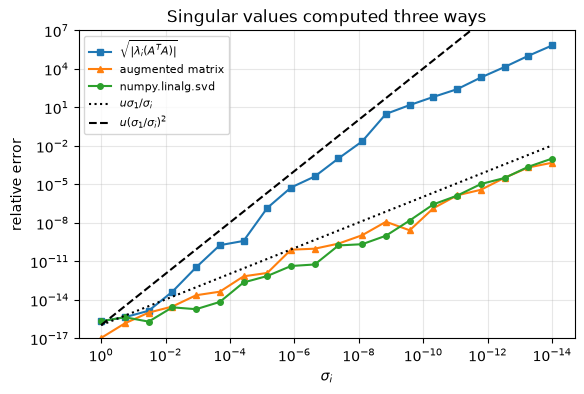

In [12]:
m, n = 30, 20
s_true = np.logspace(0, -14, n)
A = (random_orthonormal(m, n) * s_true) @ random_orthonormal(n, n).T
s_svd = np.linalg.svd(A, compute_uv=False)
lam = np.sort(np.linalg.eigvalsh(A.T @ A))[::-1]
s_eig = np.sqrt(np.abs(lam))
C = np.block([[np.zeros((n, n)), A.T], [A, np.zeros((m, m))]])
s_aug = np.sort(np.linalg.eigvalsh(C))[::-1][:n]
print(f"negative computed eigenvalues of A^T A: {int(np.sum(lam < 0))} of {n}")
print(f"max |svd - sigma| / (u sigma_1) = {np.max(np.abs(s_svd - s_true)) / u:.1f}")
print(f"max |aug - sigma| / (u sigma_1) = {np.max(np.abs(s_aug - s_true)) / u:.1f}")
print(f"max |eig(A^T A) - sigma^2| / (u sigma_1^2) = {np.max(np.abs(lam - s_true**2)) / u:.1f}")

fig, ax = plt.subplots()
floor = u / 10
ax.loglog(s_true, np.maximum(np.abs(s_eig - s_true) / s_true, floor), "s-", ms=4, label=r"$\sqrt{|\lambda_i(A^TA)|}$")
ax.loglog(s_true, np.maximum(np.abs(s_aug - s_true) / s_true, floor), "^-", ms=4, label="augmented matrix")
ax.loglog(s_true, np.maximum(np.abs(s_svd - s_true) / s_true, floor), "o-", ms=4, label="numpy.linalg.svd")
ax.loglog(s_true, u / s_true, "k:", label=r"$u\sigma_1/\sigma_i$")
ax.loglog(s_true, u / s_true**2, "k--", label=r"$u(\sigma_1/\sigma_i)^2$")
ax.set_ylim(1e-17, 1e7)
ax.invert_xaxis()
ax.set_xlabel(r"$\sigma_i$")
ax.set_ylabel("relative error")
ax.set_title("Singular values computed three ways")
ax.legend(fontsize=8)
plt.show()

# Error bounds: SVD and augmented matrix O(n u sigma_1) absolutely; A^T A route O(n u sigma_1^2) in sigma^2.
assert np.max(np.abs(s_svd - s_true)) < 10 * n * u * s_true[0]
assert np.max(np.abs(s_aug - s_true)) < 10 * n * u * s_true[0]
assert np.max(np.abs(lam - s_true**2)) < 10 * n * u * s_true[0] ** 2
# ...and that bound is useless for the small singular values: no correct digits below 1e-9.
assert np.all(np.abs(s_eig - s_true)[s_true < 1e-9] / s_true[s_true < 1e-9] > 1)

**Interpretation.** All three methods deliver *absolute* errors that are
small multiples of their natural unit: $u\sigma_1$ for the SVD and the
augmented matrix, $u\sigma_1^2$ for the eigenvalues of $A^TA$. Measured
relative to $\sigma_i$, the first two lose accuracy like $\sigma_1/\sigma_i$
and the third like $(\sigma_1/\sigma_i)^2$, so it has no correct digits once
$\sigma_i\lesssim\sqrt u\,\sigma_1\approx10^{-8}$. Some computed eigenvalues
of $A^TA$ are even negative, which a positive semidefinite matrix cannot have.

## 8. Eckart--Young--Mirsky from computed errors

For the noisy rank-8 matrix of Section 4 we form each $A_k$ explicitly,
compute $\|A-A_k\|_2$ and $\|A-A_k\|_F$ *from the difference*, and compare
with $\sigma_{k+1}$ and $(\sum_{i>k}\sigma_i^2)^{1/2}$. The theorem predicts
equality; in floating point the two sides differ by rounding errors of order
$n u\sigma_1$.

In [13]:
A = A_noisy
m, n = A.shape
U, s, Vh = np.linalg.svd(A)
tail = np.sqrt(np.cumsum((s**2)[::-1])[::-1])            # tail[k] = sqrt(sum_{i>k} sigma_i^2), 0-based
err2, errF = [], []
for k in range(n):
    Ak = (U[:, :k] * s[:k]) @ Vh[:k]
    err2.append(np.linalg.norm(A - Ak, 2))
    errF.append(np.linalg.norm(A - Ak, "fro"))
err2, errF = np.array(err2), np.array(errF)
print(" k   ||A-A_k||_2   sigma_{k+1}   ||A-A_k||_F   tail sum")
for k in (0, 1, 7, 8, 9, 30, 59):
    print(f"{k:2d}   {err2[k]:11.5g}   {s[k]:11.5g}   {errF[k]:11.5g}   {tail[k]:9.5g}")
print(f"max |computed 2-norm error - sigma_(k+1)| = {np.max(np.abs(err2 - s)):.1e}")
print(f"max |computed F-norm error - tail sum|    = {np.max(np.abs(errF - tail)):.1e}")
assert np.max(np.abs(err2 - s)) < 10 * n * u * s[0]
assert np.max(np.abs(errF - tail)) < 10 * n * u * s[0]
print(f"relative Frobenius error of A_8: {errF[8] / np.linalg.norm(A, 'fro'):.4f}")
print(f"storage of A_8: {8 * (m + n + 1)} numbers instead of {m * n}")

 k   ||A-A_k||_2   sigma_{k+1}   ||A-A_k||_F   tail sum
 0        86.606        86.606        169.88      169.88
 1        77.178        77.178        146.15      146.15
 7        36.326        36.326        36.418      36.418
 8       0.65027       0.65027        2.5897      2.5897
 9       0.64569       0.64569        2.5068      2.5068
30       0.34794       0.34794        1.0767      1.0767
59       0.01072       0.01072       0.01072     0.01072
max |computed 2-norm error - sigma_(k+1)| = 3.6e-14
max |computed F-norm error - tail sum|    = 5.7e-14
relative Frobenius error of A_8: 0.0152
storage of A_8: 968 numbers instead of 3600


The computed errors agree with the singular values to within a small
multiple of $u\sigma_1\approx10^{-14}$, as predicted, and the 2-norm and Frobenius errors are clearly different numbers:
after the gap, $\|A-A_k\|_F$ is several times $\sigma_{k+1}$.

**No competitor does better.** Eckart--Young--Mirsky is a statement about
*all* matrices of rank at most $k$. We try a few natural competitors: the
projection of $A$ onto $k$ random directions, onto the span of its first $k$
columns, and a truncated SVD of a perturbed $A$.

In [14]:
k = 8
competitors = {}
Qr = random_orthonormal(m, k)
competitors["random projection Q Q^T A"] = Qr @ (Qr.T @ A)
Qc, _ = np.linalg.qr(A[:, :k])
competitors["projection onto first k columns"] = Qc @ (Qc.T @ A)
G = 0.1 * rng.standard_normal(A.shape)
Up, sp, Vhp = np.linalg.svd(A + G)
competitors["truncated SVD of A + 0.1 G"] = (Up[:, :k] * sp[:k]) @ Vhp[:k]
print(f"{'best (A_8)':35s} 2-norm {s[k]:8.4f}   Frobenius {tail[k]:8.4f}")
for name, Bk in competitors.items():
    e2, eF = np.linalg.norm(A - Bk, 2), np.linalg.norm(A - Bk, "fro")
    print(f"{name:35s} 2-norm {e2:8.4f}   Frobenius {eF:8.4f}")
    assert np.linalg.matrix_rank(Bk) <= k
    assert e2 >= s[k] * (1 - 10 * n * u) and eF >= tail[k] * (1 - 10 * n * u)
# Stability argument of the notes: truncating the SVD of A + G costs at most 2 ||G||_2 extra.
e2_pert = np.linalg.norm(A - competitors["truncated SVD of A + 0.1 G"], 2)
print(f"sigma_9 + 2 ||G||_2 = {s[k] + 2 * np.linalg.norm(G, 2):.4f} >= {e2_pert:.4f}")
assert e2_pert <= s[k] + 2 * np.linalg.norm(G, 2)

best (A_8)                          2-norm   0.6503   Frobenius   2.5897
random projection Q Q^T A           2-norm  84.3494   Frobenius 160.2229
projection onto first k columns     2-norm  50.0008   Frobenius  50.2222
truncated SVD of A + 0.1 G          2-norm   1.1888   Frobenius   4.0066
sigma_9 + 2 ||G||_2 = 3.6548 >= 1.1888


Projecting onto random directions or onto the span of a few columns of $A$
gives poor approximations. The truncated SVD of a perturbed matrix is close
to optimal, and its excess error is within the bound
$\|A-\widetilde A_k\|_2\le\sigma_{k+1}(A)+2\|G\|_2$ derived in the notes.
Every competitor loses, as it must.

## 9. Perturbation of singular values

[Corollary 2.1](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-cor-perturbation) says $|\sigma_i(A+E)-\sigma_i(A)|\le\|E\|_2$
for every $i$, and Mirsky's theorem gives
$\big(\sum_i(\sigma_i(A+E)-\sigma_i(A))^2\big)^{1/2}\le\|E\|_F$. We test
both for perturbations of very different sizes, and compare with the
eigenvalues of a nonsymmetric matrix.

In [15]:
A = rng.standard_normal((40, 25))
s = np.linalg.svd(A, compute_uv=False)
print("  ||E||_2    max_i |d sigma_i| / ||E||_2    ||d sigma||_2 / ||E||_F")
for scale in (1e-12, 1e-6, 1e-2, 1.0):
    worst, worst_F = 0.0, 0.0
    for _ in range(20):
        E = scale * rng.standard_normal(A.shape)
        ds = np.linalg.svd(A + E, compute_uv=False) - s
        nE2, nEF = np.linalg.norm(E, 2), np.linalg.norm(E, "fro")
        worst = max(worst, np.max(np.abs(ds)) / nE2)
        worst_F = max(worst_F, np.linalg.norm(ds) / nEF)
        # Rounding in both SVDs adds up to ~ 10 n u sigma_1 to the observed difference.
        assert np.max(np.abs(ds)) <= nE2 + 20 * 40 * u * s[0]
        assert np.linalg.norm(ds) <= nEF + 20 * 40 * u * s[0] * np.sqrt(25)
    print(f"  {nE2:8.1e}   {worst:26.3f}   {worst_F:22.3f}")

  ||E||_2    max_i |d sigma_i| / ||E||_2    ||d sigma||_2 / ||E||_F
   1.1e-11                        0.307                    0.206
   9.9e-06                        0.314                    0.208
   1.1e-01                        0.254                    0.176
   1.1e+01                        0.547                    0.485


The ratios stay below $1$, as the theorems require, for perturbations
ranging over twelve orders of magnitude. For random perturbations they are
well below $1$; the bound is attained only by special perturbations such as
$E = \epsilon u_1v_1^T$.

Compare the eigenvalues of the nonsymmetric matrix
$\begin{bmatrix}0&1\\ \epsilon&0\end{bmatrix}$, which are $\pm\sqrt\epsilon$:
a perturbation of size $\epsilon$ moves them by $\sqrt\epsilon$.

In [16]:
for eps_ in (1e-4, 1e-8, 1e-16):
    J = np.array([[0.0, 1.0], [eps_, 0.0]])
    ev = np.sort(np.linalg.eigvals(J).real)
    sv = np.linalg.svd(J, compute_uv=False)
    print(f"eps = {eps_:.0e}: eigenvalues {ev}, singular values {sv}")
    # Both are computed to a few units of u relative accuracy for this 2 x 2 matrix.
    assert np.allclose(sv, [1.0, eps_], rtol=10 * u, atol=0)
    assert np.allclose(ev, [-np.sqrt(eps_), np.sqrt(eps_)], rtol=10 * u, atol=0)

eps = 1e-04: eigenvalues [-0.01  0.01], singular values [1.e+00 1.e-04]
eps = 1e-08: eigenvalues [-0.0001  0.0001], singular values [1.e+00 1.e-08]
eps = 1e-16: eigenvalues [-1.e-08  1.e-08], singular values [1.e+00 1.e-16]


The singular values move from $(1,0)$ to $(1,\epsilon)$, by exactly
$\epsilon$; the eigenvalues move from $0$ to $\pm\sqrt\epsilon$, a change
eight orders of magnitude larger than the perturbation when
$\epsilon = 10^{-16}$.

## 10. The pseudoinverse and minimum-norm least squares

We implement $A^+ = V_k\Sigma_k^{-1}U_k^T$ with an explicit relative tolerance
and verify the four Penrose conditions [(2.8)](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#equation-ch02-eq-penrose) on a
rank-deficient $10\times6$ matrix of rank 4.

In [17]:
def pinv_svd(A, rtol):
    """Pseudoinverse from the SVD, discarding singular values <= rtol * sigma_1."""
    U, s, Vh = np.linalg.svd(A, full_matrices=False)
    k = int(np.sum(s > rtol * s[0]))
    return (Vh[:k].T / s[:k]) @ U[:, :k].T, k


m, n, r = 10, 6, 4
A = rng.standard_normal((m, r)) @ rng.standard_normal((r, n))
Ap, k = pinv_svd(A, rtol=max(m, n) * np.finfo(float).eps)
s = np.linalg.svd(A, compute_uv=False)
kappa_r = s[0] / s[r - 1]                                # conditioning of the rank-r part
conditions = {
    "(i)   ||A X A - A||": np.linalg.norm(A @ Ap @ A - A, 2) / np.linalg.norm(A, 2),
    "(ii)  ||X A X - X||": np.linalg.norm(Ap @ A @ Ap - Ap, 2) / np.linalg.norm(Ap, 2),
    "(iii) ||(AX)^T - AX||": np.linalg.norm((A @ Ap).T - A @ Ap, 2),
    "(iv)  ||(XA)^T - XA||": np.linalg.norm((Ap @ A).T - Ap @ A, 2),
}
print(f"numerical rank used: {k};  sigma_1/sigma_r = {kappa_r:.1f}")
for name, val in conditions.items():
    print(f"{name:25s} {val:.1e}")
    # relative residuals of order kappa_r * n u for a backward stable SVD
    assert val < 100 * n * kappa_r * u
diff = np.linalg.norm(Ap - np.linalg.pinv(A), 2) / np.linalg.norm(Ap, 2)
print(f"||X - numpy.linalg.pinv(A)|| / ||X|| = {diff:.1e}")
assert k == r and diff < 100 * n * kappa_r * u

numerical rank used: 4;  sigma_1/sigma_r = 7.7
(i)   ||A X A - A||       3.8e-16
(ii)  ||X A X - X||       4.1e-16
(iii) ||(AX)^T - AX||     1.2e-15
(iv)  ||(XA)^T - XA||     4.0e-16
||X - numpy.linalg.pinv(A)|| / ||X|| = 7.6e-17


Now the minimum-norm least-squares solution ([Theorem 2.9](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-thm-min-norm)).
Every least-squares solution has the same residual, and $A^+b$ is the one of
smallest norm; adding a null-space vector keeps the residual and increases the
norm. `numpy.linalg.lstsq` also returns the minimum-norm solution.

In [18]:
b = rng.standard_normal(m)
x_plus = Ap @ b
x_lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
null_vec = np.linalg.svd(A)[2][r:].T @ rng.standard_normal(n - r)   # a vector in N(A)
x_other = x_plus + null_vec
for name, x in [("A^+ b", x_plus), ("lstsq", x_lstsq), ("A^+ b + null vector", x_other)]:
    print(f"{name:22s} ||Ax - b|| = {np.linalg.norm(A @ x - b):.12f}   ||x|| = {np.linalg.norm(x):.6f}")
assert np.linalg.norm(x_plus - x_lstsq) < 100 * n * kappa_r * u * np.linalg.norm(x_plus)
assert abs(np.linalg.norm(A @ x_other - b) - np.linalg.norm(A @ x_plus - b)) < 100 * n * u * np.linalg.norm(b)
assert np.linalg.norm(x_other) > np.linalg.norm(x_plus)
# The residual is orthogonal to range(A) (normal equations).
assert np.linalg.norm(A.T @ (A @ x_plus - b)) < 100 * n * kappa_r * u * np.linalg.norm(A, 2) * np.linalg.norm(b)

# Exercise ch02-ex-min-norm:
A_ex, b_ex = np.array([[1.0, 1.0], [1.0, 1.0]]), np.array([1.0, 3.0])
print("minimum-norm solution of the exercise:", np.linalg.pinv(A_ex) @ b_ex)
assert np.allclose(np.linalg.pinv(A_ex) @ b_ex, [1.0, 1.0], rtol=0, atol=10 * u)

A^+ b                  ||Ax - b|| = 1.851305465391   ||x|| = 0.405170
lstsq                  ||Ax - b|| = 1.851305465391   ||x|| = 0.405170
A^+ b + null vector    ||Ax - b|| = 1.851305465391   ||x|| = 2.241986
minimum-norm solution of the exercise: [1. 1.]


**The pseudoinverse is discontinuous.** For $A_\epsilon = \operatorname{diag}(1,\epsilon)$
the norm $\|A_\epsilon^+\|_2 = 1/\epsilon$ explodes as $\epsilon\to0$,
unless a tolerance treats $\epsilon$ as zero. The default relative cutoff of
`numpy.linalg.pinv` is $10^{-15}$.

In [19]:
for eps_ in (1e-3, 1e-10, 1e-14, 1e-16, 0.0):
    Ae = np.diag([1.0, eps_])
    default = np.linalg.norm(np.linalg.pinv(Ae), 2)
    truncated = np.linalg.norm(np.linalg.pinv(Ae, rcond=1e-8), 2)
    print(f"eps = {eps_:7.0e}:  ||pinv(A)|| default = {default:9.3g},  with rcond = 1e-8: {truncated:g}")

eps =   1e-03:  ||pinv(A)|| default =     1e+03,  with rcond = 1e-8: 1000
eps =   1e-10:  ||pinv(A)|| default =     1e+10,  with rcond = 1e-8: 1
eps =   1e-14:  ||pinv(A)|| default =     1e+14,  with rcond = 1e-8: 1
eps =   1e-16:  ||pinv(A)|| default =         1,  with rcond = 1e-8: 1
eps =   0e+00:  ||pinv(A)|| default =         1,  with rcond = 1e-8: 1


With the default cutoff, $\|A_\epsilon^+\|$ is $10^{14}$ at $\epsilon = 10^{-14}$
and then drops to $1$ below the cutoff: a jump by fourteen orders of
magnitude caused by an arbitrary threshold. If $\epsilon$ represents noise,
the cutoff should be set from the noise level, as in Section 4.

## 11. How NumPy computes the SVD

`numpy.linalg.svd` calls LAPACK's `gesdd`, which reduces $A$ to bidiagonal
form and then uses a divide-and-conquer method. `scipy.linalg.svd` also
defaults to `gesdd` but can use `gesvd`, the implicit QR iteration of Golub,
Kahan and Reinsch. Both are backward stable, so their singular values must
agree to about $u\sigma_1$. Their run times differ, and the difference depends
on the machine and the LAPACK library; the numbers below are observations on
the machine that executed this notebook. The four computations are timed in
turn, so that changes in the load of the machine during the measurement
affect all of them alike.

In [20]:
def median_times(methods, repeats=7):
    """Median run time of each method, timing the methods in turn in every repeat."""
    for f in methods.values():
        f()                                               # warm-up
    samples = {name: [] for name in methods}
    for _ in range(repeats):
        for name, f in methods.items():
            t0 = time.perf_counter()
            f()
            samples[name].append(time.perf_counter() - t0)
    return {name: float(np.median(times)) for name, times in samples.items()}


n = 400
A = rng.standard_normal((n, n))
s_dd = sla.svd(A, compute_uv=False, lapack_driver="gesdd")
s_qr = sla.svd(A, compute_uv=False, lapack_driver="gesvd")
s_np = np.linalg.svd(A, compute_uv=False)
print(f"max |gesdd - gesvd| / (u sigma_1) = {np.max(np.abs(s_dd - s_qr)) / (u * s_dd[0]):.1f}")
assert np.max(np.abs(s_dd - s_qr)) < 10 * n * u * s_dd[0]
assert np.max(np.abs(s_dd - s_np)) < 10 * n * u * s_dd[0]
timings = median_times({
    "gesdd, values only": lambda: sla.svd(A, compute_uv=False, lapack_driver="gesdd"),
    "gesdd, U and V": lambda: sla.svd(A, lapack_driver="gesdd"),
    "gesvd, U and V": lambda: sla.svd(A, lapack_driver="gesvd"),
    "eigvalsh(A^T A) (do not use)": lambda: np.linalg.eigvalsh(A.T @ A),
})
for name, t_ in timings.items():
    print(f"{name:30s} {1e3 * t_:8.1f} ms (median of 7)")

max |gesdd - gesvd| / (u sigma_1) = 0.0


gesdd, values only                 15.4 ms (median of 7)
gesdd, U and V                     47.6 ms (median of 7)
gesvd, U and V                    160.9 ms (median of 7)
eigvalsh(A^T A) (do not use)       30.3 ms (median of 7)


Computing the singular vectors takes several times as many flops as the
singular values alone, and `gesdd` is usually faster than `gesvd` when vectors
are wanted; the timings above normally show both effects, but on a busy
machine individual measurements can vary by a factor of several.
Whatever the eigenvalue route through $A^TA$ costs on a given machine,
Section 7 showed that it is not accurate; speed is no argument for a method
that returns wrong answers.

## Common mistakes

- Treating `Vh` as $V$. `numpy.linalg.svd` returns $V^T$; the right singular
  vectors are the *rows* of `Vh`.
- Requesting the full SVD of a tall matrix (`full_matrices=True` is the
  default) and running out of memory.
- Comparing singular vectors from two programs entrywise. They are defined
  only up to sign (and up to rotations within repeated singular values);
  compare subspaces or fix the signs first, as in Section 2.
- Computing singular values as `np.sqrt(np.linalg.eigvals(A.T @ A))`.
- Printing $\|A-A_k\|_F$ next to $\sigma_{k+1}$ and calling them equal. The
  Frobenius error is $(\sum_{i>k}\sigma_i^2)^{1/2}$.
- Plotting "errors" computed from the singular values instead of from $A-A_k$:
  that assumes the theorem you meant to check.
- Deciding rank with `matrix_rank` defaults when the data are noisy, or
  using `pinv` without thinking about its cutoff.

## Your turn

1. Repeat Section 7 with $\sigma_i$ spaced from $1$ to $10^{-6}$ only. Which
   method is now adequate, and for which $i$?
2. Do [Exercise 2.11](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-ex-lauchli): vary $\delta$ and explain each column of your
   table.
3. For the noisy matrix of Section 4, increase the noise level from $0.05$ to
   $5$ and find the level at which the numerical rank with $\tau = \|N\|_2$ is
   no longer $8$. Compare with the condition $\sigma_8(\hat A) > 2\|N\|_2$ of
   [Proposition 2.2](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/notes.html#ch02-prop-numerical-rank).
4. Construct a perturbation $E$ with $\|E\|_2 = 10^{-3}$ that changes
   $\sigma_3$ of a random matrix by exactly $10^{-3}$.

## Key takeaways

- The SVD exists for every matrix, and NumPy computes it with a backward
  stable divide-and-conquer algorithm (`gesdd`); verify factors with
  tolerances of order $\max(m,n)u$.
- Rank, subspaces, norms and condition numbers can all be read from the SVD,
  but rank needs a tolerance chosen from the uncertainty in the data.
- Singular values are perfectly conditioned in absolute terms: they move by
  at most $\|E\|_2$. Computed singular values therefore have absolute errors of
  order $u\sigma_1$, and computing them through $A^TA$ squares this to
  $u\sigma_1^2$.
- The truncated SVD is the best low-rank approximation in the 2- and
  Frobenius norms, with *different* errors $\sigma_{k+1}$ and
  $(\sum_{i>k}\sigma_i^2)^{1/2}$; check them from the actual differences.
- The pseudoinverse is discontinuous; truncate before inverting.

## Further reading

Trefethen and Bau (1997), Lectures 4, 5 and 31; Golub and Van Loan (2013),
Sections 2.4 and 8.6; Demmel (1997), Chapter 5. The case study of this
chapter, which applies the truncated SVD to an image, is part of the
[online notes](https://aalsammani.github.io/numerical-linear-algebra/ch02-svd/case-study-image-compression.html).